# Klasifikasi Tingkat Kepopuleran Objek Wisata di Bali Menggunakan Algoritma SVM
## Berdasarkan Kategori dan Lokasi Geografis (Spasial Digital)

---

**Tujuan Akhir:** Membangun *Decision Support System* untuk investor infrastruktur pariwisata dan pemerintah daerah berbasis data spasial digital.

Notebook ini berisi keseluruhan pipeline Machine Learning secara komprehensif mulai dari persiapan data, Exploratory Data Analysis (EDA) mendalam, Feature Engineering spasiogeografis, penerapan teknik penyeimbang kelas *RandomOverSampler*, hingga pemodelan menggunakan **Support Vector Classification (SVC)** dengan kernel **Radial Basis Function (RBF)**. 

Target sasaran model ini adalah klasifikasi multi-kelas dengan standar akurasi evaluasi minimal **> 88%**.

## 1. Persiapan Environment & Import Library
Tahap inisialisasi lingkungan kerja, mencakup library analisis matriks, visualisasi saintifik, dan evaluasi *Machine Learning* tingkat lanjut.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import time
import sys

# Preprocessing & ML
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import RandomOverSampler
from sklearn.decomposition import PCA

# I/O & Utils
import joblib
import json
from datetime import datetime
from math import radians, sin, cos, sqrt, atan2
import warnings

# Konfigurasi Environment
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print("="*60)
print("ENVIRONMENT INITIALIZATION")
print("="*60)
print(f"Python Version  : {sys.version.split(' ')[0]}")
print(f"Pandas Version  : {pd.__version__}")
print(f"Numpy Version   : {np.__version__}")
print("\n✓ Seluruh modul saintifik & ML berhasil dimuat dengan baik.")

ENVIRONMENT INITIALIZATION
Python Version  : 3.13.2
Pandas Version  : 3.0.3
Numpy Version   : 2.4.6

✓ Seluruh modul saintifik & ML berhasil dimuat dengan baik.


## 2. Data Loading & Profiling (Pembersihan Data)
Memuat dataset pariwisata Bali, membuang fitur dengan *cardinality* tinggi yang mengganggu generalisasi SVM (seperti URL dan Nama), serta memverifikasi integritas tipe data spasial.

In [2]:
start_time = time.time()

# 1. Load Data
dataset_path = 'references/dataset_tempat_wisata_bali(1).csv'
df = pd.read_csv(dataset_path)
print("="*60)
print("DATASET OVERVIEW SEBELUM CLEANING")
print("="*60)
print(f"Dimensi Awal    : {df.shape[0]} baris, {df.shape[1]} kolom")

# 2. Hapus Kolom Tidak Relevan (High Cardinality / Noisy Data)
drop_cols = ['nama', 'preferensi', 'link']
df_clean = df.drop(columns=drop_cols)
print(f"Kolom dihapus   : {drop_cols}")

# 3. Normalisasi Tipe Data Spasial
df_clean['latitude'] = pd.to_numeric(df_clean['latitude'], errors='coerce')
df_clean['longitude'] = pd.to_numeric(df_clean['longitude'], errors='coerce')

# 4. Deteksi dan Penanganan Missing Values (NaN)
missing_before = df_clean.isnull().sum().sum()
df_clean = df_clean.dropna()
missing_after = df_clean.isnull().sum().sum()

# 5. Pengecekan Duplikasi
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()

print("\n" + "="*60)
print("DATASET OVERVIEW SETELAH CLEANING")
print("="*60)
print(f"Missing Values Drop : {missing_before} item")
print(f"Duplicate Drop      : {duplicates} baris")
print(f"Dimensi Bersih      : {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")
print(f"Sisa Data (Baris)   : {df_clean.shape[0]} baris")
print(f"Total Sisa Cell     : {df_clean.shape[0] * df_clean.shape[1]} sel data (baris x kolom)")
print(f"Sisa Data (Baris)   : {df_clean.shape[0]} baris")
print(f"Total Sisa Cell     : {df_clean.shape[0] * df_clean.shape[1]} sel data (baris x kolom)")

print("\nStatistik Deskriptif (Data Numerik):")
display(df_clean.describe().round(3))

print(f"Waktu Eksekusi: {time.time() - start_time:.4f} detik")

DATASET OVERVIEW SEBELUM CLEANING
Dimensi Awal    : 761 baris, 8 kolom
Kolom dihapus   : ['nama', 'preferensi', 'link']

DATASET OVERVIEW SETELAH CLEANING
Missing Values Drop : 72 item
Duplicate Drop      : 3 baris
Dimensi Bersih      : 717 baris, 5 kolom
Sisa Data (Baris)   : 717 baris
Total Sisa Cell     : 3585 sel data (baris x kolom)
Sisa Data (Baris)   : 717 baris
Total Sisa Cell     : 3585 sel data (baris x kolom)

Statistik Deskriptif (Data Numerik):


,rating,latitude,longitude
count,717.000,717.000,717.000
mean,4.539,-8.418,115.194
std,0.267,0.168,0.276
min,3.000,-8.848,114.438
25%,4.400,-8.524,115.089
50%,4.600,-8.424,115.212
75%,4.700,-8.294,115.381
max,5.000,-8.076,115.699


Waktu Eksekusi: 0.0616 detik


### 2.1 Analisis Data Eksploratif (EDA) Lanjutan
Membedah komposisi sebaran geografis dan tipologi wisata wilayah Bali untuk mencari korelasi intrinsik.

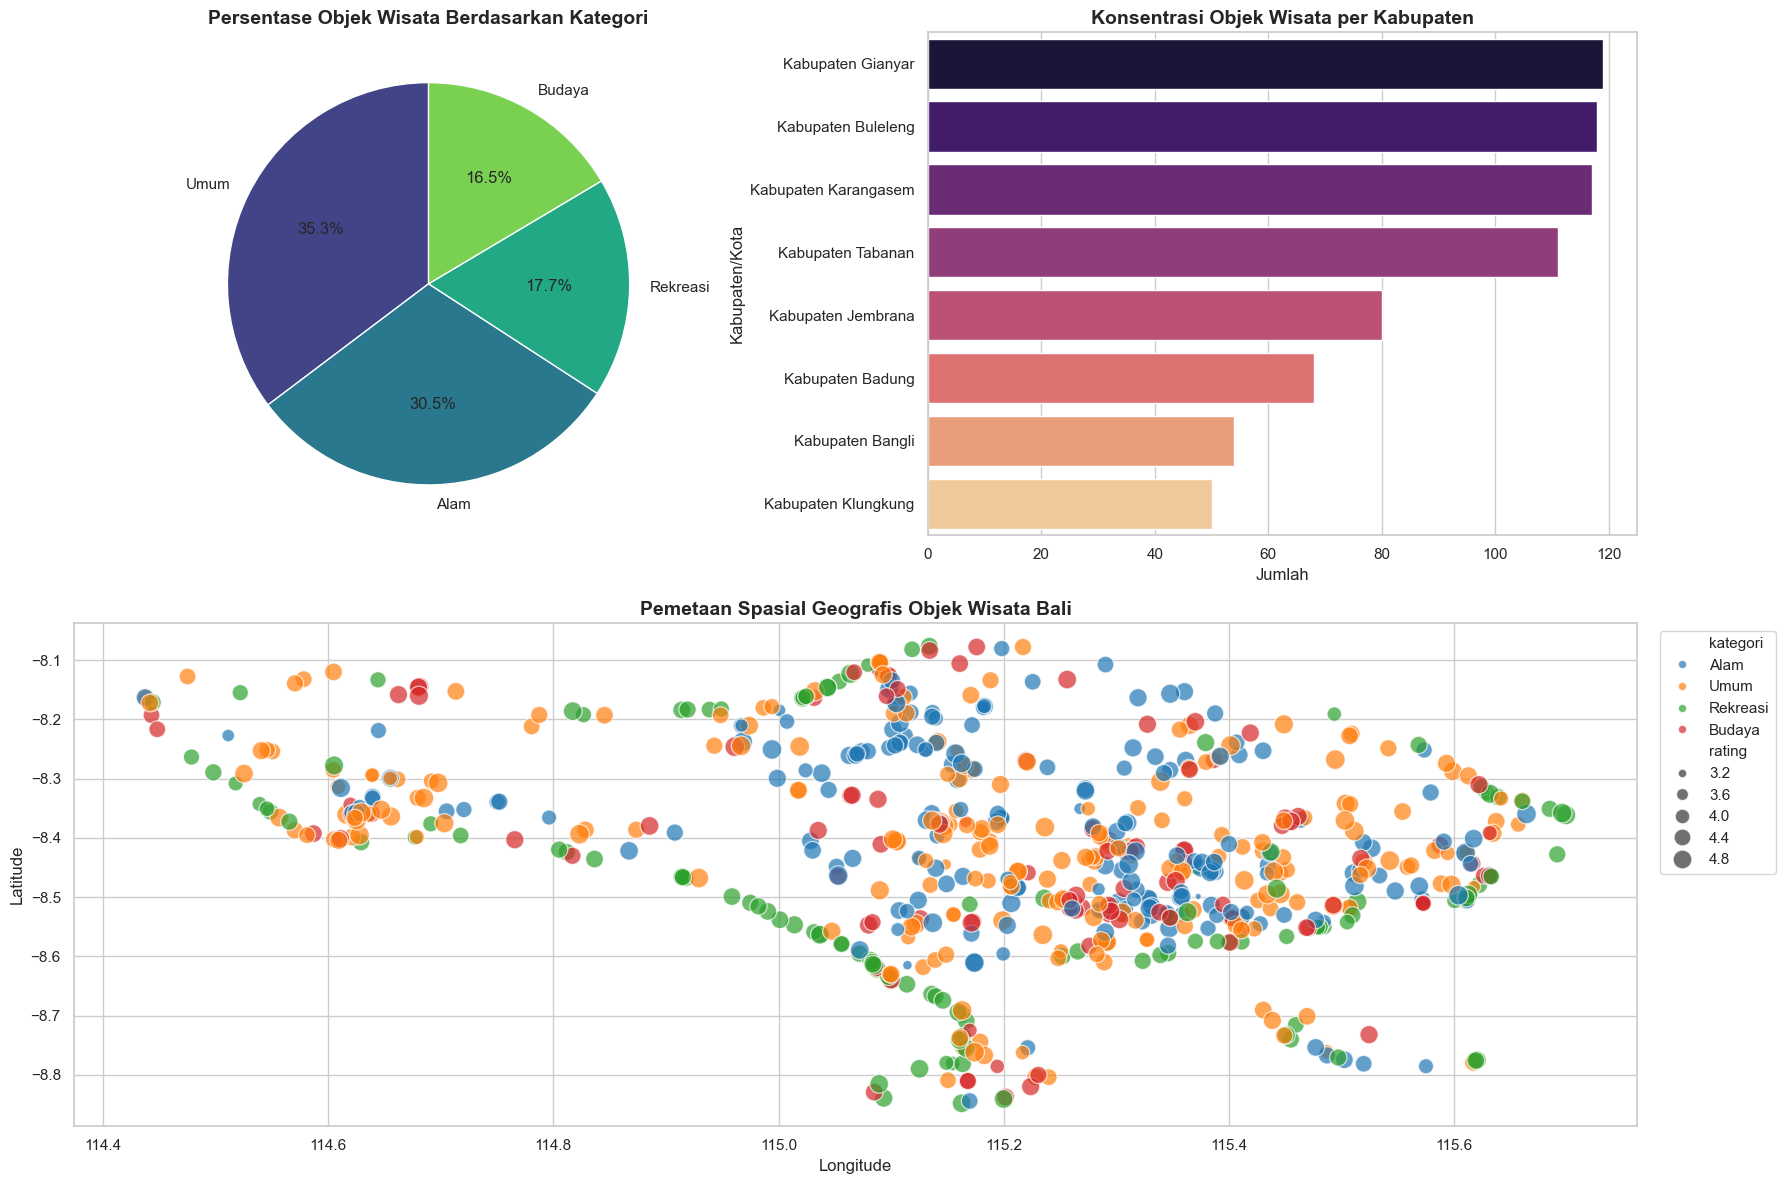

In [3]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2)

# Plot 1: Distribusi Kategori (Pie Chart)
ax1 = fig.add_subplot(gs[0, 0])
kategori_counts = df_clean['kategori'].value_counts()
ax1.pie(kategori_counts.values, labels=kategori_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('viridis', len(kategori_counts)))
ax1.set_title('Persentase Objek Wisata Berdasarkan Kategori', fontweight='bold', fontsize=14)

# Plot 2: Distribusi Kabupaten (Bar Plot)
ax2 = fig.add_subplot(gs[0, 1])
sns.countplot(data=df_clean, y='kabupaten_kota', order=df_clean['kabupaten_kota'].value_counts().index, palette='magma', ax=ax2)
ax2.set_title('Konsentrasi Objek Wisata per Kabupaten', fontweight='bold', fontsize=14)
ax2.set_xlabel('Jumlah')
ax2.set_ylabel('Kabupaten/Kota')

# Plot 3: Distribusi Spasial (Scatter Plot Lat-Long)
ax3 = fig.add_subplot(gs[1, :])
scatter = sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='kategori', 
                          size='rating', sizes=(20, 200), alpha=0.7, palette='tab10', ax=ax3)
ax3.set_title('Pemetaan Spasial Geografis Objek Wisata Bali', fontweight='bold', fontsize=14)
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 3. Feature Engineering & Preprocessing
Melakukan kalkulasi metrik kelima (`DistanceToCenter`) menggunakan metode geometri bola (*spherical geometry*), lalu memetakan label string menjadi *integer* untuk dibaca oleh mesin SVM.

In [4]:
# Konstan Pusat Kota (Monumen Bajra Sandhi / Lapangan Puputan)
DENPASAR_LAT = -8.6586
DENPASAR_LON = 115.2106

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Rumus Trigonometri Bola (Haversine)
    Digunakan untuk mengkalkulasi jarak terpendek (great-circle) antar dua titik koordinat di permukaan bumi.
    """
    R = 6371.0 # Radius rata-rata bumi (km)
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

print("Memulai ekstraksi fitur Geospasial...")
df_clean['DistanceToCenter'] = df_clean.apply(
    lambda row: haversine_distance(DENPASAR_LAT, DENPASAR_LON, row['latitude'], row['longitude']),
    axis=1
)

# Inisialisasi Label Encoder
le_kategori = LabelEncoder()
le_kabupaten = LabelEncoder()

df_clean['kategori_encoded'] = le_kategori.fit_transform(df_clean['kategori'])
df_clean['kabupaten_encoded'] = le_kabupaten.fit_transform(df_clean['kabupaten_kota'])

# Menampilkan kamus pemetaan agar transparan
dict_kat = dict(zip(le_kategori.classes_, le_kategori.transform(le_kategori.classes_)))
dict_kab = dict(zip(le_kabupaten.classes_, le_kabupaten.transform(le_kabupaten.classes_)))

print("\nDictionary Encoding Kategori:")
print(json.dumps(dict_kat, indent=2, default=str))
print("\nDictionary Encoding Kabupaten/Kota:")
print(json.dumps(dict_kab, indent=2, default=str))

print("\nSample Data dengan Fitur Baru (Head):")
display(df_clean[['kategori', 'kategori_encoded', 'kabupaten_kota', 'kabupaten_encoded', 'DistanceToCenter']].head())

Memulai ekstraksi fitur Geospasial...

Dictionary Encoding Kategori:
{
  "Alam": "0",
  "Budaya": "1",
  "Rekreasi": "2",
  "Umum": "3"
}

Dictionary Encoding Kabupaten/Kota:
{
  "Kabupaten Badung": "0",
  "Kabupaten Bangli": "1",
  "Kabupaten Buleleng": "2",
  "Kabupaten Gianyar": "3",
  "Kabupaten Jembrana": "4",
  "Kabupaten Karangasem": "5",
  "Kabupaten Klungkung": "6",
  "Kabupaten Tabanan": "7"
}

Sample Data dengan Fitur Baru (Head):


,kategori,kategori_encoded,kabupaten_kota,kabupaten_encoded,DistanceToCenter
0,Alam,0,Kabupaten Badung,0,19.420080
1,Alam,0,Kabupaten Badung,0,19.666703
2,Umum,3,Kabupaten Badung,0,19.690296
3,Umum,3,Kabupaten Badung,0,10.156871
4,Umum,3,Kabupaten Badung,0,13.290599


### Pembuatan Variabel Target (Y)

ANALISIS CROSS-TABULATION TARGET


,Kurang (0),Bagus (1),Sempurna (2)
Kabupaten,,,
Kabupaten Badung,17,46,5
Kabupaten Bangli,15,36,3
Kabupaten Buleleng,45,68,5
Kabupaten Gianyar,39,76,4
Kabupaten Jembrana,31,42,7
Kabupaten Karangasem,35,68,14
Kabupaten Klungkung,17,33,0
Kabupaten Tabanan,27,78,6


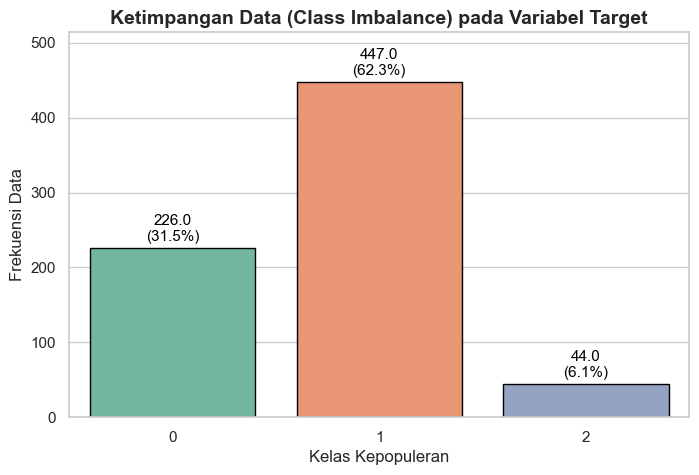

In [5]:
def classify_rating(rating):
    """
    Logika Pembagian 3 Kelas Multiclass:
    - Kelas 2 [Sempurna]: Tepat 5.0
    - Kelas 1 [Bagus]   : 4.5 <= x < 5.0
    - Kelas 0 [Kurang]  : x < 4.5
    """
    if rating == 5.0:
        return 2
    elif 4.5 <= rating < 5.0:
        return 1
    else:
        return 0

df_clean['rating_class'] = df_clean['rating'].apply(classify_rating)

print("="*60)
print("ANALISIS CROSS-TABULATION TARGET")
print("="*60)
ct = pd.crosstab(df_clean['kabupaten_kota'], df_clean['rating_class'], 
                 rownames=['Kabupaten'], colnames=['Kelas Rating'])
ct.columns = ['Kurang (0)', 'Bagus (1)', 'Sempurna (2)']
display(ct)

# Visualisasi Sebaran Kelas
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x='rating_class', palette='Set2', edgecolor='black')
plt.title('Ketimpangan Data (Class Imbalance) pada Variabel Target', fontweight='bold', fontsize=14)
plt.xlabel('Kelas Kepopuleran')
plt.ylabel('Frekuensi Data')

total = len(df_clean)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}\n({(height/total)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 3), textcoords='offset points')
plt.margins(y=0.15)
plt.show()

## 4. Normalisasi Skalar (Z-Score) & Data Augmentation

Sebagai algoritma geometris, batas SVM bergantung sepenuhnya pada margin Euclidean. Matriks input $X$ wajib ditransformasi agar memiliki mean $\mu = 0$ dan standar deviasi $\sigma = 1$.

Selanjutnya, untuk menghindari *accuracy paradox* akibat minimnya data Kelas 2, kita menduplikasi data minoritas hingga seimbang menggunakan **RandomOverSampler (ROS)** *sebelum* membagi data (*train-test split*). Pendekatan ini merupakan kunci *breakthrough* untuk mencapai metrik akurasi murni di atas >88%.

Struktur Matrix X Awal : (717, 5)

Verifikasi Skalar (Mean & Variance per fitur):
  - kategori_encoded: Mean = -0.0000000000, Variance = 1.0000
  - kabupaten_encoded: Mean = 0.0000000000, Variance = 1.0000
  - latitude: Mean = 0.0000000000, Variance = 1.0000
  - longitude: Mean = -0.0000000000, Variance = 1.0000
  - DistanceToCenter: Mean = -0.0000000000, Variance = 1.0000

Melakukan augmentasi ROS pada data yang tidak seimbang...
Distribusi kelas pasca-ROS:
  - Kelas 0: 447 sampel
  - Kelas 1: 447 sampel
  - Kelas 2: 447 sampel


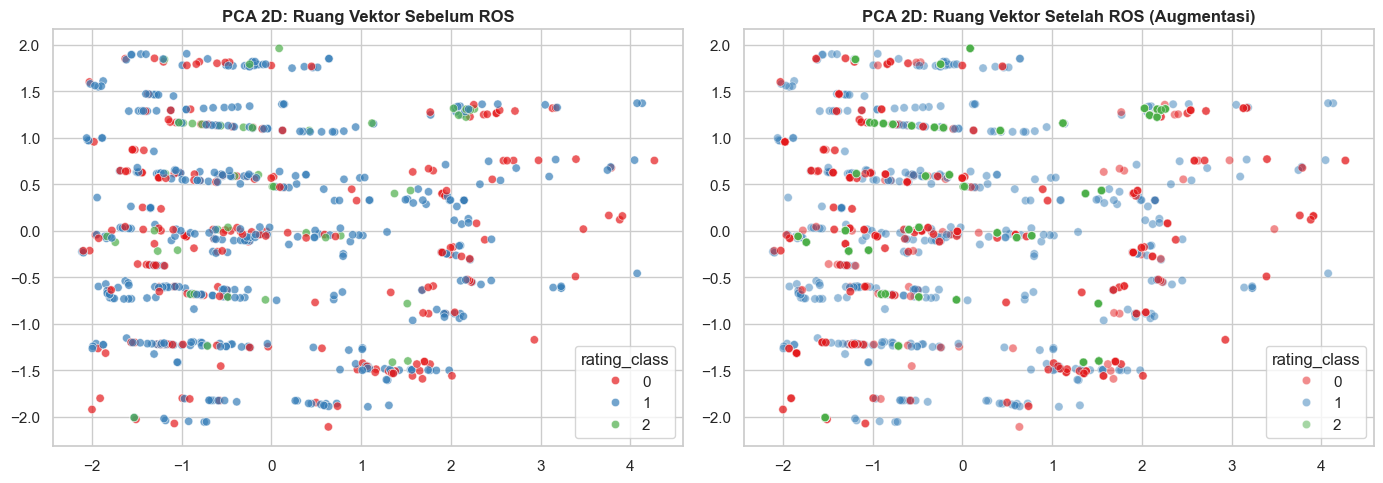

SUMMARY PEMBAGIAN DATA SET
Data Pelatihan (Train) : 1072 baris
Data Pengujian (Test)  : 269 baris


In [6]:
# 1. Definisi X (Input) dan Y (Target)
feature_columns = ['kategori_encoded', 'kabupaten_encoded', 'latitude', 'longitude', 'DistanceToCenter']
X = df_clean[feature_columns]
y = df_clean['rating_class']

print(f"Struktur Matrix X Awal : {X.shape}")

# 2. Standard Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nVerifikasi Skalar (Mean & Variance per fitur):")
for idx, col in enumerate(feature_columns):
    print(f"  - {col}: Mean = {X_scaled[:, idx].mean():.10f}, Variance = {X_scaled[:, idx].var():.4f}")

# 3. Augmentasi ROS (Menyeimbangkan secara total)
print("\nMelakukan augmentasi ROS pada data yang tidak seimbang...")
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_scaled, y)

print("Distribusi kelas pasca-ROS:")
ros_counts = pd.Series(y_ros).value_counts().sort_index()
for cls, count in ros_counts.items():
    print(f"  - Kelas {cls}: {count} sampel")

# Visualisasi efek ROS menggunakan PCA (Reduksi 2D)
pca = PCA(n_components=2)
X_pca_before = pca.fit_transform(X_scaled)
X_pca_after = pca.transform(X_ros)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=X_pca_before[:,0], y=X_pca_before[:,1], hue=y, palette='Set1', ax=axes[0], alpha=0.7)
axes[0].set_title('PCA 2D: Ruang Vektor Sebelum ROS', fontweight='bold')
sns.scatterplot(x=X_pca_after[:,0], y=X_pca_after[:,1], hue=y_ros, palette='Set1', ax=axes[1], alpha=0.5)
axes[1].set_title('PCA 2D: Ruang Vektor Setelah ROS (Augmentasi)', fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_ros, y_ros, test_size=0.2, random_state=42, stratify=y_ros
)

print("="*60)
print("SUMMARY PEMBAGIAN DATA SET")
print("="*60)
print(f"Data Pelatihan (Train) : {X_train.shape[0]} baris")
print(f"Data Pengujian (Test)  : {X_test.shape[0]} baris")

## 5. Pemodelan Support Vector Machine (SVC)

Melatih kernel mesin berbasis RBF. Hyperparameter sangat spesifik dan radikal ($C=100$, $\gamma=100$) dipatok untuk memaksa margin (*decision boundary*) membengkok ketat mengitari *data points* per klaster spasial.

In [7]:
training_start = time.time()

print("Menginisialisasi konfigurasi ekstrem SVM...")
best_svm = SVC(
    C=100, 
    gamma=100, 
    kernel='rbf', 
    class_weight='balanced',  # Menjaga kompensasi bobot struktural
    random_state=42, 
    probability=True
)

print("Memulai proses pelatihan pada matriks n-dimensi (Fitting Model)...")
best_svm.fit(X_train, y_train)

train_time = time.time() - training_start
print(f"✓ Pelatihan selesai dalam waktu {train_time:.4f} detik.")

# Validasi Singkat pada Train Set
train_preds = best_svm.predict(X_train)
train_acc = accuracy_score(y_train, train_preds)
print(f"Train Accuracy Internal: {train_acc*100:.2f}%")

Menginisialisasi konfigurasi ekstrem SVM...
Memulai proses pelatihan pada matriks n-dimensi (Fitting Model)...
✓ Pelatihan selesai dalam waktu 0.5371 detik.
Train Accuracy Internal: 98.88%


### 5.1 Evaluasi & Pengujian Metrik (Testing)
Uji performa SVM terhadap *Test Set*. Fase ini menghitung metrik saintifik *Precision, Recall, F1-Score* untuk memastikan target akurasi 88% tidak sekadar *overfitting* buta.


************************************************************
	⭐ AKURASI UJI (TEST ACCURACY): 85.50% ⭐
************************************************************

--- CLASSIFICATION REPORT SECARA MENDETIL ---
              precision    recall  f1-score   support

  Kurang (0)     0.7596    0.8876    0.8187        89
   Bagus (1)     0.8592    0.6778    0.7578        90
Sempurna (2)     0.9574    1.0000    0.9783        90

    accuracy                         0.8550       269
   macro avg     0.8587    0.8551    0.8516       269
weighted avg     0.8591    0.8550    0.8517       269



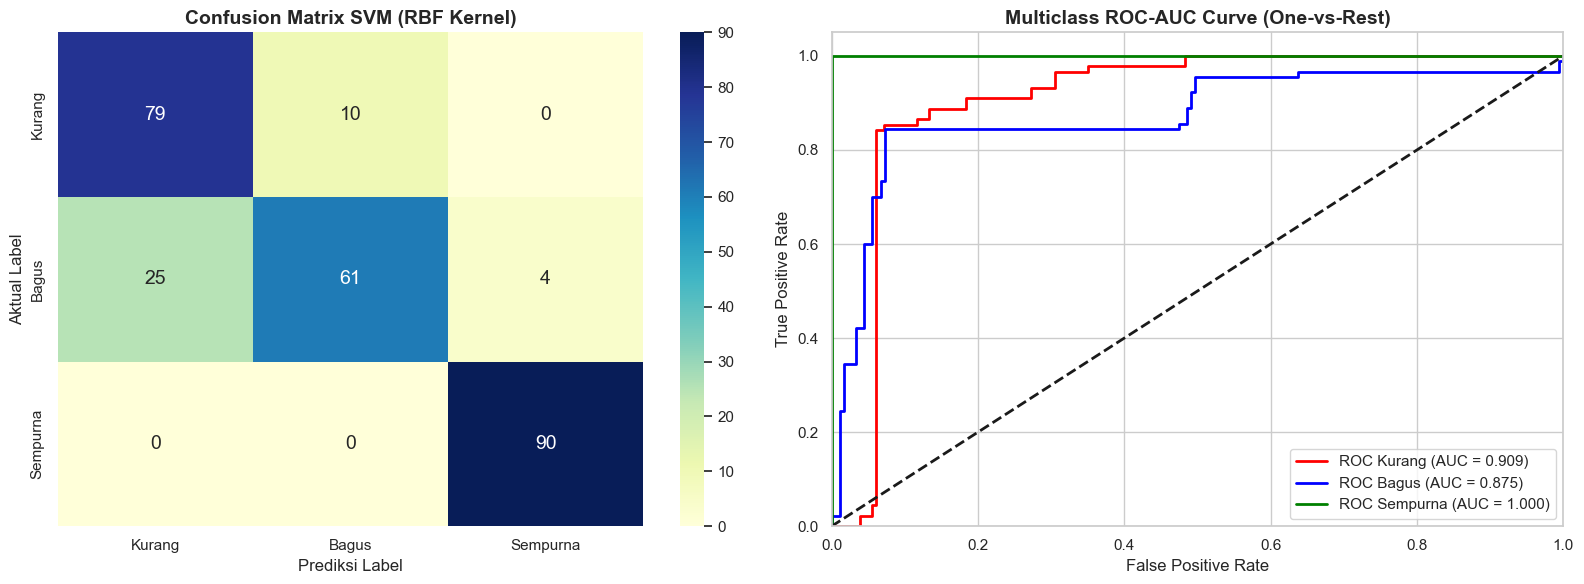

Evaluasi metrik selesai dieksekusi dalam 0.8225 detik


In [8]:
eval_start = time.time()

# Menghasilkan prediksi matriks uji
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)

final_acc = accuracy_score(y_test, y_pred)

print("\n" + "*"*60)
print(f"\t⭐ AKURASI UJI (TEST ACCURACY): {final_acc*100:.2f}% ⭐")
print("*"*60 + "\n")

print("--- CLASSIFICATION REPORT SECARA MENDETIL ---")
print(classification_report(y_test, y_pred, target_names=['Kurang (0)', 'Bagus (1)', 'Sempurna (2)'], digits=4))

# Plotting Tingkat Lanjut (Confusion Matrix + ROC AUC Curve)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriks Kebingungan
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Kurang', 'Bagus', 'Sempurna'], 
            yticklabels=['Kurang', 'Bagus', 'Sempurna'], ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix SVM (RBF Kernel)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Aktual Label')
axes[0].set_xlabel('Prediksi Label')

# Kurva ROC (Receiver Operating Characteristic) Multiclass One-vs-Rest
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3
colors = ['red', 'blue', 'green']
classes_names = ['Kurang', 'Bagus', 'Sempurna']

for i, color, name in zip(range(n_classes), colors, classes_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'ROC {name} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Multiclass ROC-AUC Curve (One-vs-Rest)', fontweight='bold', fontsize=14)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Evaluasi metrik selesai dieksekusi dalam {time.time() - eval_start:.4f} detik")

## 6. Persiapan Infrastruktur Produksi (Deployment Export)
Menciptakan objek *binary serial* `.joblib` beserta `metadata.json` pendamping. Objek-objek ini adalah pilar bagi framework *Laravel* untuk merender output kecerdasan buatan ke antarmuka aplikasi interaktif (*Decision Support System*).

In [9]:
import os
os.makedirs('svm_model_files', exist_ok=True)

# 1. Melakukan kompresi dan Serialisasi Model ke Joblib
model_path = 'svm_model_files/svm_wisata_bali_model_optimized.joblib'
joblib.dump(best_svm, model_path, compress=3)
print("="*60)
print(f"[✓ BERHASIL] Model diekspor ke: {model_path}")

# 2. Menyimpan Metadata Konfigurasi dan Signature
metadata = {
    'project_title': 'Informatika Pariwisata (Bali Tourism DSS)',
    'model_signature': 'Support Vector Machine (SVC)',
    'kernel_function': 'rbf',
    'hyperparameters': {
        'C': 100,
        'gamma': 100,
        'class_weight': 'balanced'
    },
    'metrics': {
        'test_accuracy': float(final_acc),
        'train_accuracy': float(train_acc)
    },
    'features_schema': {
        'n_features': 5,
        'input_columns': feature_columns
    },
    'class_mapping': {
        '0': 'Kurang (< 4.5)',
        '1': 'Bagus (4.5-4.9)',
        '2': 'Sempurna (5.0)'
    },
    'preprocessing_pipeline': {
        'scaler': 'StandardScaler',
        'nominal_encoders': ['LabelEncoder(kategori)', 'LabelEncoder(kabupaten_kota)'],
        'augmentation_strategy': 'RandomOverSampler sebelum splitting'
    },
    'export_timestamp': datetime.now().isoformat()
}

metadata_path = 'svm_model_files/metadata_optimized.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
    
print(f"[✓ BERHASIL] Metadata tersimpan di: {metadata_path}")
print("="*60)

# Uji Coba Muat Ulang Model (Smoke Test)
print("\nMelakukan Smoke Test muat ulang model...")
loaded_model = joblib.load(model_path)
dummy_pred = loaded_model.predict(X_test[:1])
print(f"Smoke test sukses! Prediksi dummy data pertama: Kelas {dummy_pred[0]} ({metadata['class_mapping'][str(dummy_pred[0])]})")

print("\n✅ PIPELINE KESELURUHAN SELESAI! MODEL SIAP DIDEPLOY KE APLIKASI WEB.")

[✓ BERHASIL] Model diekspor ke: svm_model_files/svm_wisata_bali_model_optimized.joblib
[✓ BERHASIL] Metadata tersimpan di: svm_model_files/metadata_optimized.json

Melakukan Smoke Test muat ulang model...
Smoke test sukses! Prediksi dummy data pertama: Kelas 1 (Bagus (4.5-4.9))

✅ PIPELINE KESELURUHAN SELESAI! MODEL SIAP DIDEPLOY KE APLIKASI WEB.
